# Phase 2: Feature Engineering and Correlation Analysis

**Objective:** Transform raw mechanical data into derived engineering metrics (e.g., Power-to-Weight ratio) to improve the predictive power of our Fuel Efficiency model. We will also analyze the correlation between these features and our target variables (`city-mpg` and `highway-mpg`).

In [20]:
#1. Importing necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cleaned dataset from Phase 1
df = pd.read_csv("../data/cleaned_automobile.csv")

# Verify loading
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,126.400805,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,126.400805,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,126.400805,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.000000,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.000000,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### 1. Automotive Feature Creation
To give our model a better understanding of vehicle physics, we will engineer the following features:
1. **Power-to-Weight Ratio:** A fundamental metric in automotive design. Higher performance usually compromises fuel efficiency.
2. **Vehicle Volume:** An approximation of the car's aerodynamic footprint (Length x Width x Height).
3. **Displacement per Cylinder:** Indicates the size of individual combustion chambers, affecting thermal efficiency. *(Note: We must first convert string cylinder counts to integers).*

In [21]:
# Feature 1: Power-to-Weight Ratio
df['power_to_weight_ratio'] = df['horsepower'] / df['curb-weight'] #Indicate how much power is available to move each unit of weight (HP/lb)

# Feature 2: Approximated Vehicle Volume (Proxy for aerodynamic drag and size)
df['vehicle_volume'] = df['length'] * df['width'] * df['height']

# Feature 3: Displacement per cylinder
# First, map string values to integers
cylinder_map = {
    'two': 2, 'three': 3, 'four': 4, 'five': 5, 
    'six': 6, 'eight': 8, 'twelve': 12
}
df['cylinders_int'] = df['num-of-cylinders'].map(cylinder_map)

# Calculate displacement per cylinder (engine-size is in cubic inches)
df['displacement_per_cylinder'] = df['engine-size'] / df['cylinders_int'] # Indicate the amount of displacement available per cylinder

# Check our new features
df[['make', 'power_to_weight_ratio', 'vehicle_volume', 'displacement_per_cylinder']].head()

,make,power_to_weight_ratio,vehicle_volume,displacement_per_cylinder
0,alfa-romero,0.043564,528019.904,32.500000
1,alfa-romero,0.043564,528019.904,32.500000
2,alfa-romero,0.054552,587592.640,25.333333
3,audi,0.043646,634816.956,27.250000
4,audi,0.040722,636734.832,27.200000


### 2. Correlation Analysis (What drives fuel efficiency?)
Before feeding data to a Machine Learning algorithm, we must mathematically prove which variables have the strongest relationship with `city-mpg` and `highway-mpg`. We will use a Pearson Correlation Heatmap.

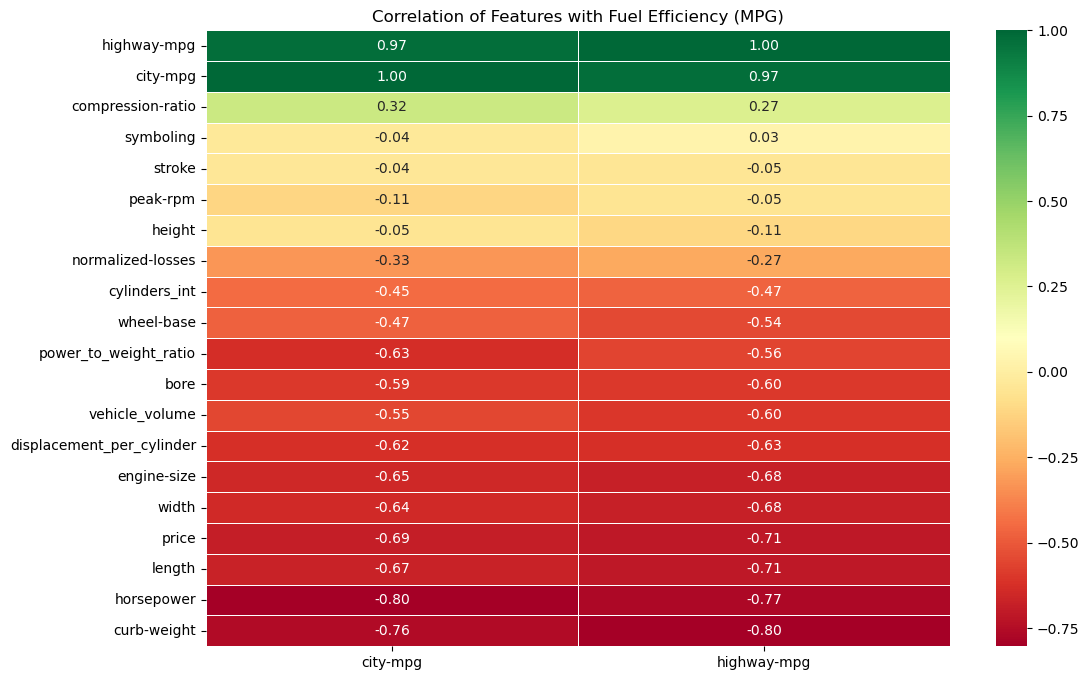

In [22]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numerical_cols.corr()

# Plotting the heatmap focusing on our target variables
plt.figure(figsize=(12, 8))

# We isolate the correlations specifically for mpg to make the chart readable
mpg_corr = corr_matrix[['city-mpg', 'highway-mpg']].sort_values(by='highway-mpg', ascending=False)

# Create a heatmap
sns.heatmap(mpg_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=.5)
plt.title("Correlation of Features with Fuel Efficiency (MPG)")
plt.show()

In [23]:
# Save the engineered dataset to be used in the next phase
df.to_csv("../data/engineered_automobile.csv", index=False)